# Plotly: Data Visualization in Python - Line, Bar, Scatter, Histogram, Violin, Gantt, Heatmap, 3D graphs

## Introduction

- Plotyly is powerful Python Visualization library for creating **interactive** and **publication-quality** graphs.
- It supports various plot type, making it ideal for **data exploration and storytelling.**
- For this case study, we analyze **Tourism & Travel Analytics,** focusing on trends in **visitors numbers, seasonal patterns, hotel bookings and travel costs.**

## Plotly: Interactive Visualization for Tourism & travel Analytics

### Line Plot

#### Concept

A **line plot** is used to visualize trends over time, making it ideal for **time-series data** like monthly tourist arrivals.

In [10]:
# Loading Data set

import pandas as pd
import plotly.express as px
df = pd.read_csv('tourism_data.csv')
df.head()

,Month,Tourist_Arrivals,Country,Average_Travel_Cost,Hotel_Bookings,Hotel_Price,Season,Start_Date,End_Date,Activity,Hotel_Rating
0,Jan,12000,USA,800,300,100,Winter,2025-01-05,2025-01-10,Sightseeing,4.5
1,Feb,15000,UK,750,280,120,Winter,2025-02-10,2025-02-15,Adventure Sports,4.2
2,Mar,18000,Germany,900,320,130,Spring,2025-03-15,2025-03-20,Cultural Tour,4.7
3,Apr,21000,France,850,310,110,Spring,2025-04-20,2025-04-25,Beach Holiday,4.3
4,May,25000,India,700,290,140,Summer,2025-05-25,2025-05-30,Mountain Trek,4.1


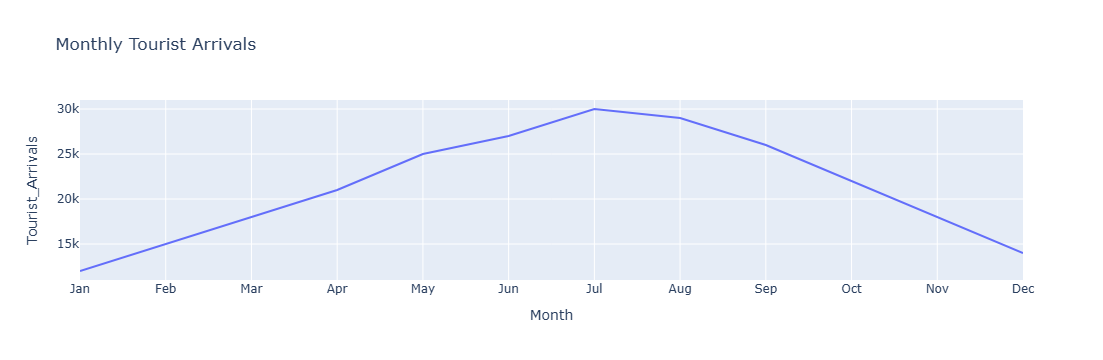

In [11]:
#### Tourism Trends Over Time

fig = px.line(df, x = 'Month', y = 'Tourist_Arrivals', title = 'Monthly Tourist Arrivals')
fig.show()

#### What is your observation/Inference?
**->**

- The graph helps **identify seasonal trends.**
- Peak may indicate **holiday seasons**, while dips suggest **off-seasons.**
- Between May to September it peak season for tourist.
- From October to December it is declining and lowest in January.
- From January to July it is upward trend and August to December trend.

### Bar Plot

#### Concept

A **bar chart** compares categories, making it suitable for **analyzing top source countries for tourism.**

#### Tourist Arrivals by Country



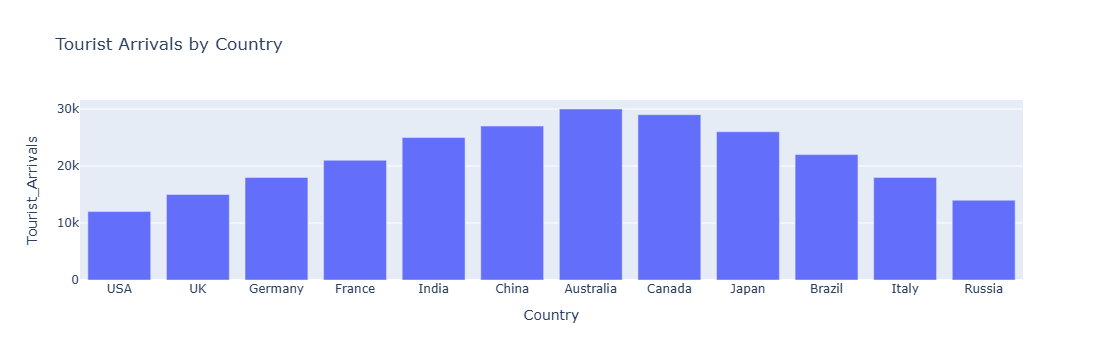

In [12]:
fig = px.bar(df, x = 'Country', y = 'Tourist_Arrivals', title = 'Tourist Arrivals by Country')
fig.show()

#### Inference

- The highest bars indicate **major contributors to tourism**, that is Australia around 30k after thatcanada 29k.
- The lowest bar indicate USA that is around 12k.
- Useful for **targeted marketing campaings**.

### Scatter Plot

#### Concept

A **scatter plot** helps to visualize relationships between **two numerical variables.**

#### Hotel Bookings vs. Travel Costs

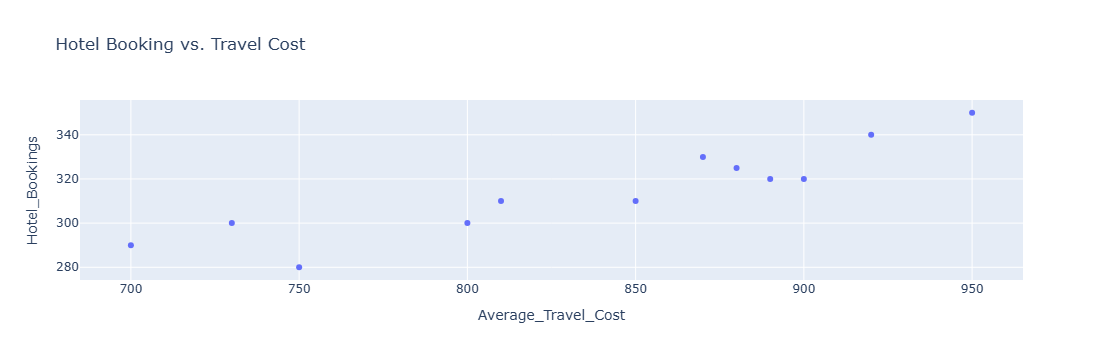

In [13]:
fig = px.scatter(df, x = 'Average_Travel_Cost', y = 'Hotel_Bookings', title = 'Hotel Booking vs. Travel Cost')
fig.show()

#### Inference:

- If booking **increase with cost,** tourists may prefer luxury travel.
- If **inverse correlation**, budget-conscious tourism dominates.

### Histogram

#### Concept

A **histogram** shows the frequency distribution of numerical data, making it useful for analyzing hotel pricing.

#### Distribution of Hotel Proces

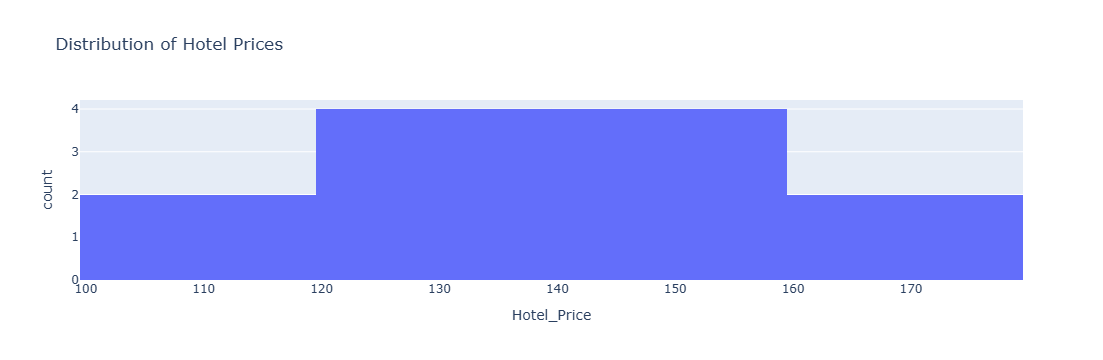

In [14]:
fig = px.histogram(df, x = 'Hotel_Price', title = "Distribution of Hotel Prices")
fig.show()

#### Inference

- Identifies whether hotels are **affordable or expensive**.
- Peaks show the **most common price range**.

### Violin Plot

#### Concept

A **violin plot** combines **a box plot and KDE**(Kernel Density Estimation) to show **data distribution with density estimation**.

#### Seasonal Variation in Travel Cost


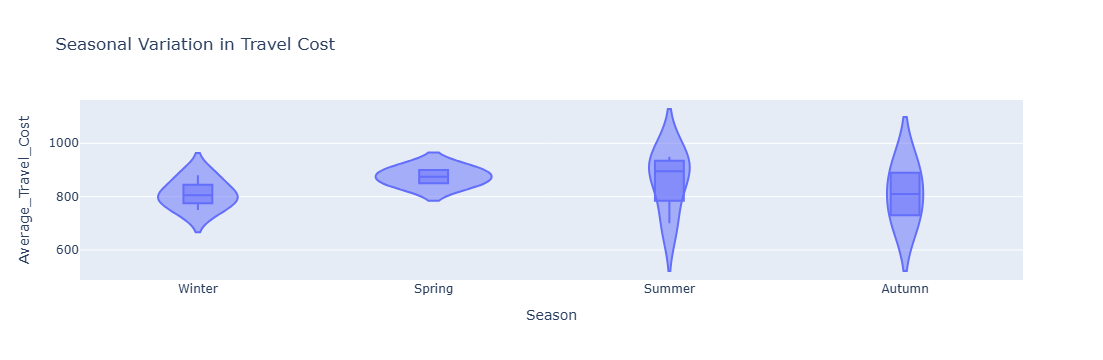

In [15]:
fig = px.violin(df, x = 'Season', y = 'Average_Travel_Cost', box = True, title = ' Seasonal Variation in Travel Cost')
fig.show()

#### Inference:

- Wider areas indicates **most frequent travel costs.**
- Outliner help **identify premium or budget travel trends.**
- Highest Travel Cost: Summer has the higgest average travel cost at approximately 1000 units.
- Lowest Travel Costs: Winter has the lowest average travel cost at around 500 units, making it the most affordable season travel.
- Trend: Travel costs rise steadily from Winter to Summer, Peak in Summer and the decline in Autumm, Suggesting a cyclical pattern tied to seasonal demand.


### Gantt Chart

A **Gantt Chart** visualizes schedules, making it ideal for **trip planning**.

#### Travel Itinerary Planning

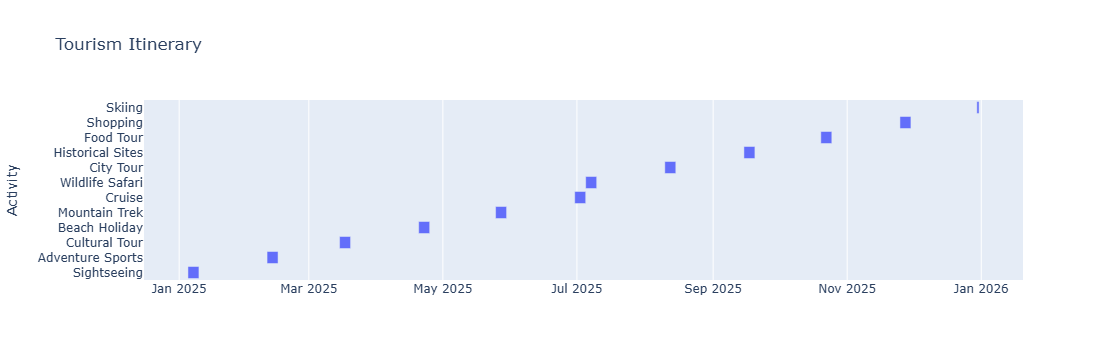

In [16]:
fig = px.timeline(df, x_start = 'Start_Date', x_end= 'End_Date', y = 'Activity', title= 'Tourism Itinerary')
fig.show()

#### Inference

- **Seasonal Activities**: The itenary includes seasonal activities like "Skiing"(likely in winter months like Jan or Nov) and "Beach Holiday"(likely in summer months like Jul), suggesting travels plan by weather and time of year.
- **Diverse Options**: The list covers a wide range of interests(adventure, culture, relaxation), indicating a flexible or multi-purpose travel plan spanning 2025-2026
- **Possible Gaps**: Months like Feb, Apr, Jun etc.. are missing, implying either no travel planned or focus or specific periods.

### Heatmap

#### Concept

A **heatmap** is useful for **finding patterns and correlations.**

#### Correlation between Travel Features

In [17]:
import numpy as np
import plotly.figure_factory as ff

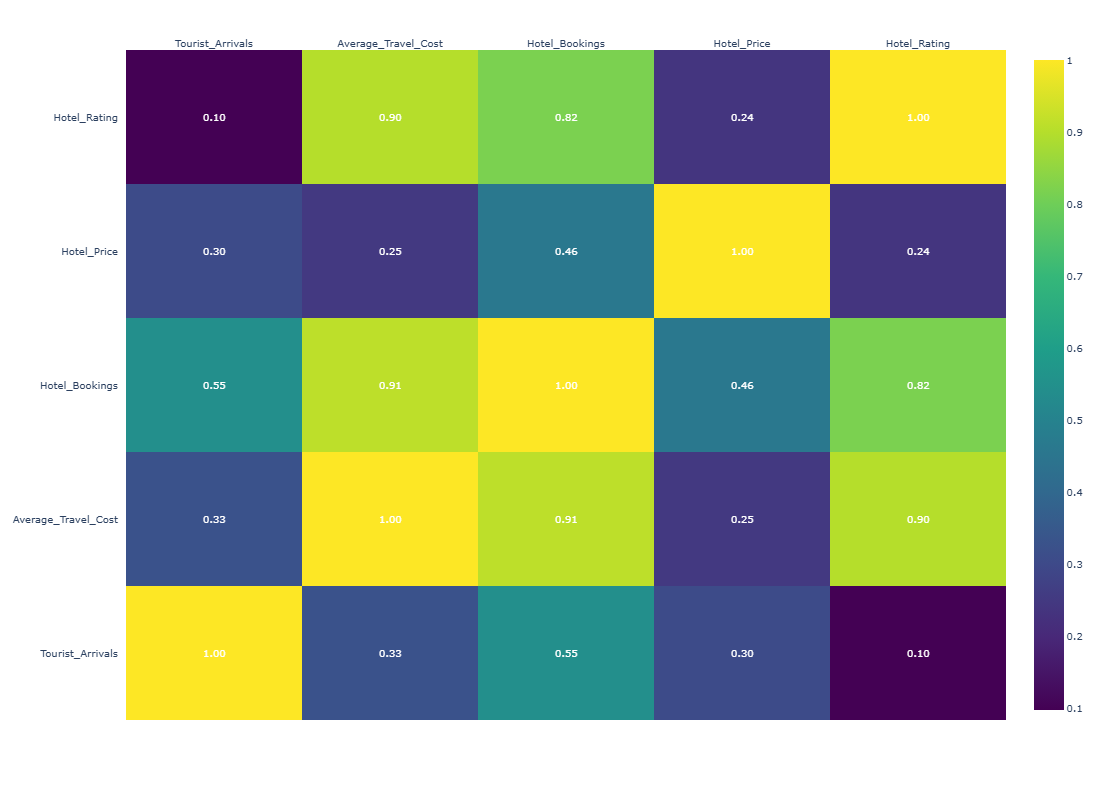

In [18]:
import plotly.figure_factory as ff

# Compute correlation matrix (numerical columns only)
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Create annotated heatmap
fig = ff.create_annotated_heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns.tolist(),
    y=correlation_matrix.index.tolist(),
    colorscale='Viridis',
    showscale=True,  # fixed typo
    annotation_text=[[f"{val:.2f}" for val in row] for row in correlation_matrix.values],
    font_colors=["white"]
)

# Update layout for spacing and readability
fig.update_layout(
    width=800,
    height=800,
    margin=dict(t=50, l=100),
    font=dict(size=10)
)

fig.show()

#### Inference:

- **Strongest Driver of Bookings**: There is a very high correlation (0.91) between Average Travel Cost and Hotel Bookings, as well as between Hotel Rating and Hotel Bookings (0.82). This suggests that travelers are highly influenced by perceived quality and the overall investment in their trip.

- **Travel Cost & Rating Link**: A strong correlation of 0.90 between Hotel Rating and Average Travel Cost indicates that higher-rated, premium accommodations are the primary drivers of increased travel expenditures.

- **Volume vs. Quality**: Interestingly, Tourist Arrivals has a weak correlation with Hotel Rating (0.10). This implies that a high volume of tourists doesn't necessarily mean they are staying in luxury or high-rated hotels; mass tourism may lean toward budget options.

- **Price Elasticity**: Hotel Price shows a moderate correlation with Hotel Bookings (0.46). This suggests that while price matters, it is less of a deciding factor for bookings than the hotel's rating or the traveler's total budget.

#### Overall: 

Quality (Ratings) and overall Travel Cost are the dominant factors driving Booking behavior, whereas pure Arrival volume has the least impact on the luxury/rating segment.

### 3D Plot

#### Concept

A **3D scatter plot** provides a **multi-dimensional view of relationship**.

#### Travel Cost vs Hotel Rating & Bookings
    

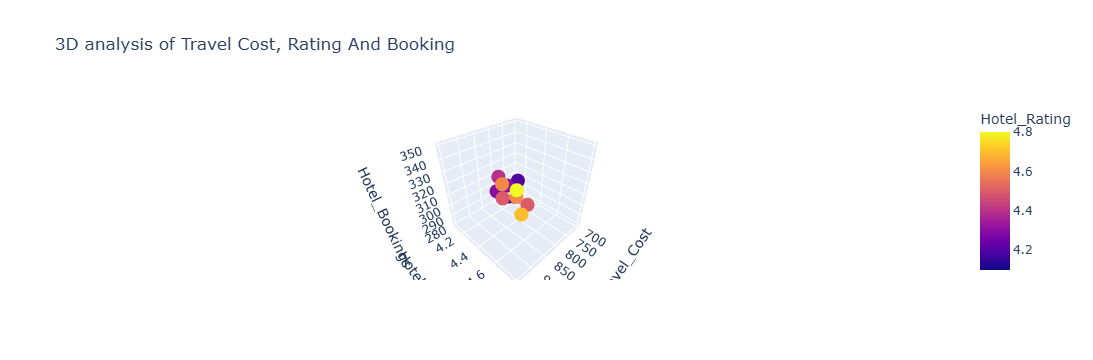

In [19]:
fig = px.scatter_3d(df, x = 'Average_Travel_Cost', y = 'Hotel_Rating', z = 'Hotel_Bookings', 
                    title = "3D analysis of Travel Cost, Rating And Booking", color = 'Hotel_Rating')
fig.show()

### Inference

- Helps compare **luxury vs. budget travel trends**.

- Identifies clusters of **popular hotel price ranges**.

- Positive Correlation Between Hotel Rating and Bookings: Higher-rated hotels (e.g., 4.8–4.9) tend to have more bookings, indicating that customers prioritize quality and ratings when choosing accommodations.

- Travel Cost Impact on Bookings: Mid-range travel costs may correlate with higher bookings, as customers likely balance affordability with quality. Extremely high or low travel costs could show fewer bookings, suggesting a preference for value-for-money options.

- Rating Consistency Matters: Hotels with ratings around 4.4–4.5 appear frequently, suggesting this range is common or optimal for attracting bookings while maintaining competitive pricing. Lower ratings (e.g., 4.0–4.2) may indicate fewer bookings or less customer preference.

## Conclusion

Plotly provides **interactive and insightful visualization**, making it essentail for **tourism data analysis.**

With **Interactivity, responsiveness and rich features**, Plotly enhances decion-making in travel industry.
                                                                                  

